In [1]:
import os
nthreads = 1
os.environ["OMP_NUM_THREADS"] = str(nthreads)
os.environ["OPENBLAS_NUM_THREADS"] = str(nthreads)
os.environ["MKL_NUM_THREADS"] = str(nthreads)

In [ ]:
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
import inferagni as ia
import pandas as pd
from cmcrameri import cm
from copy import deepcopy

from inferagni.plot import truth_color, samples_color, DPI

/home/harrison/miniforge3/envs/proteus/lib/python3.12/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/harrison/.var/app/com.visualstudio.code/config', but the default location, /home/harrison/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


In [3]:
# %config InlineBackend.figure_format = 'retina'

In [4]:
outdir = "output/TOI-421_b/"

In [5]:
samps = pd.read_csv(outdir+"result.csv",skiprows=1, sep=",", encoding="utf-8")
truth = pd.read_csv(outdir+"truth.csv" ,skiprows=1, sep=",", encoding="utf-8")

ntruth = len(truth)

# get last samples from samps
end_frac = 0.01
nsamp = int(len(samps)*(1-end_frac))
samps = samps.iloc[-nsamp:]

In [6]:
print(truth.keys())
print(samps.keys())

Index(['key', 'value', 'plus', 'minus'], dtype='str')
Index(['Teff', 'instellation', 'logZ', 'logCO', 'mass_tot', 'frac_core',
       'frac_atm', 't_surf', 'log_vmr_CO', 'log_vmr_H2S', 'log_vmr_CO2',
       'μ_phot', 'r_phot', 'log_vmr_H2O', 'log_vmr_H2'],
      dtype='str')


In [7]:
print(samps["μ_phot"])

175      0.002829
176      0.002611
177      0.003811
178      0.002227
179      0.002557
           ...   
17495    0.003908
17496    0.004868
17497    0.003897
17498    0.002974
17499    0.002259
Name: μ_phot, Length: 17325, dtype: float64


In [1]:

fig,ax = plt.subplots(ntruth,1,figsize=(5,0.8*ntruth),sharex=True)

for i in range(ntruth):
    k = truth["key"].iloc[i]

    this_samp = ia.util.undimen(deepcopy(samps[k]), k)

    pctle = 0.5
    ymin = np.percentile(this_samp, pctle)
    ymax = np.percentile(this_samp, 100-pctle)

    nbins = 14
    if ia.util.varprops[k].log:
        ax[i].set_yscale("log")
        bins = np.logspace(np.log10(ymin), np.log10(ymax), nbins)
    else:
        bins = np.linspace(ymin, ymax, nbins)

    # samples from mcmc
    ax[i].hist(this_samp, bins=bins, weights=np.full_like(this_samp, 100.0/len(this_samp)),
               orientation="horizontal", color=samples_color, edgecolor="none",)
    # ax[i].axhline(y=np.median(this_samp), color=samples_color, ls="dotted", alpha=0.7, lw=2)

    # observations
    al = 0.5

    this_truth = deepcopy(truth.iloc[i])
    obs_val = ia.util.undimen(this_truth["value"], k)
    ax[i].axhline(obs_val, color=truth_color, ls="-", alpha=al)

    obs_err_plu = obs_val + ia.util.undimen(this_truth["plus"], k)
    ax[i].axhline(obs_err_plu, color=truth_color, ls="--", alpha=al)

    obs_err_min = obs_val - ia.util.undimen(this_truth["minus"], k)
    ax[i].axhline(obs_err_min, color=truth_color, ls="--", alpha=al)

    # text = ia.util.varprops[k].label
    # ax[i].text(0.5, 0.5, text, transform=ax[i].transAxes, ha="left", va="center",
    #                fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.1))

    ax[i].set_ylabel(ia.util.varprops[k].label_short, fontsize=9)

    # custom tick spacing
    match k:
        case "mass_tot":
            dy = 1
            ax[i].yaxis.set_major_locator(mpl.ticker.MultipleLocator(1))
            ax[i].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.5))
        case "r_phot":
            ax[i].yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
            ax[i].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
        case "Teff":
            ax[i].yaxis.set_major_locator(mpl.ticker.MultipleLocator(200))
            ax[i].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(100))
        case "μ_phot":
            ax[i].yaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
            ax[i].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))

ax[-1].set_xlabel(f"Percentage of samples")
fig.align_ylabels()


fig.subplots_adjust(hspace=0.1)
fig.savefig(outdir+"ia_demo_truth.pdf", dpi=ia.plot.DPI, bbox_inches="tight")
plt.show()

NameError: name 'plt' is not defined

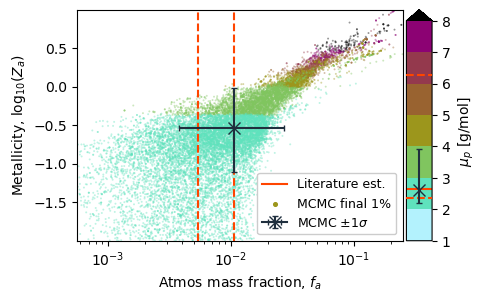

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(5,3))

ckey = "μ_phot"
xkey = "frac_atm"
ykey = "logZ"

if ia.util.varprops[ckey].log:
    c = 10**(samps[ckey].values)
else:
    c = samps[ckey].values
mask = np.argsort(c)[::-1]

x = ia.util.undimen(samps[xkey].iloc[mask], xkey)
y = ia.util.undimen(samps[ykey].iloc[mask], ykey)
c = ia.util.undimen(c[mask], ckey)

# create scalarmappable with defined boundaries
cmap = deepcopy(ia.util.varprops[ckey].cmap)
cmap.set_over("k")
norm = mpl.colors.BoundaryNorm(boundaries=np.arange(1, 9, 1.0), ncolors=cmap.N)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)


# colorbar
cbar = fig.colorbar(sm, ax=ax, label=ia.util.varprops[ckey].label, pad=0.01, extend='max', aspect=9)
cbar.ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(1))

# add paper constraints
obs_col = truth_color
cbar.ax.axhline(ia.util.undimen(truth[truth["key"]==ckey]["value"], ckey), c=obs_col, ls='-')
cbar.ax.axhline(ia.util.undimen(truth[truth["key"]==ckey]["value"], ckey) + ia.util.undimen(truth[truth["key"]==ckey]["plus"], ckey),c=obs_col , ls='--', zorder=10)
cbar.ax.axhline(ia.util.undimen(truth[truth["key"]==ckey]["value"], ckey) - ia.util.undimen(truth[truth["key"]==ckey]["minus"], ckey),c=obs_col, ls='--', zorder=10)
for xx in (0.54/100, 1.05/100):
    ax.axvline(xx, color=obs_col, ls='--')
ax.plot([],[], color=obs_col, ls='-', label="Literature est.")

# mcmc result
ax.scatter([],[], color=sm.to_rgba(4), s=28, marker=".", label=f"MCMC final {end_frac*100:g}%", zorder=21, )
ax.scatter(x,y, c=c, s=2,  alpha=0.4, cmap=sm.get_cmap(), norm=sm.norm, edgecolors="none", rasterized=True)
ax.errorbar([np.median(x)], [np.median(y)], xerr=[[np.median(x)-np.percentile(x, 16)], [np.percentile(x, 84)-np.median(x)]],
            yerr=[[np.median(y)-np.percentile(y, 16)], [np.percentile(y, 84)-np.median(y)]],
            zorder=20, label=r"MCMC $\pm 1\sigma$", capsize=2, color=samples_color, lw=1.5, marker='x', markersize=8)
cbar.ax.errorbar([0.5], [np.median(c)], yerr=[[np.median(c)-np.percentile(c, 16)], [np.percentile(c, 84)-np.median(c)]],
                 c=samples_color, markersize=8, marker='x', zorder=21,capsize=2, lw=1.5)

if ia.util.varprops[xkey].log:
    ax.set_xscale("log")
if ia.util.varprops[ykey].log:
    ax.set_yscale("log")
ax.set_xlabel(ia.util.varprops[xkey].label)
ax.set_ylabel(ia.util.varprops[ykey].label)

ax.set_xlim(np.amin(x), np.amax(x))
ax.set_ylim(np.amin(y), np.amax(y))

ax.legend(loc='lower right', fontsize=9, framealpha=1)
fig.savefig(outdir+"ia_demo_litcomp.pdf", dpi=DPI, bbox_inches="tight")
plt.show()